In [1]:
# Importing the Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.ensemble import RandomForestClassifier

In [2]:
# load the dataset
dataset = pd.read_excel('BBDM Project.xlsx')

In [3]:
# Display distribution of classes
dataset['RMC'].value_counts()

IV     4543
III    2164
V       172
Name: RMC, dtype: int64

In [4]:
# Encode the target variable
encoder = LabelEncoder()
dataset['RMC'] = encoder.fit_transform(dataset['RMC'])
# Store the original class names for later use
original_class_names = encoder.classes_

In [5]:
# Prepare Features and Target
X = dataset.drop(columns='RMC', axis=1)
Y = dataset['RMC']

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Handling class imbalance using SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, Y_train_resampled = smote.fit_resample(X_train, Y_train)

# Data Standardization
scaler = RobustScaler()
X_train_standardized = scaler.fit_transform(X_train_resampled)
X_test_standardized = scaler.transform(X_test)

# Train your classification model (Random Forest in this example)
classifier = RandomForestClassifier(random_state=42, max_depth=10, max_features='auto', min_samples_leaf=2, min_samples_split=10, n_estimators=50)
classifier.fit(X_train_standardized, Y_train_resampled)

# Make predictions on training set
Y_train_pred = classifier.predict(X_train_standardized)

# Evaluate the model on training set
print("Training Set:")
print("Accuracy: {:.3f}".format(accuracy_score(Y_train_resampled, Y_train_pred)))

C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


Training Set:
Accuracy: 0.920


In [6]:
# Make predictions on testing set
Y_test_pred = classifier.predict(X_test_standardized)


# Decode the predicted labels to their original values
Y_pred_decoded = encoder.inverse_transform(Y_test_pred)
Y_test_decoded = encoder.inverse_transform(Y_test)

# Evaluate the model on testing set
print("\nTesting Set:")
print("Accuracy: {:.3f}".format(accuracy_score(Y_test_decoded, Y_pred_decoded)))
print("Classification Report:\n", classification_report(Y_test_decoded, Y_pred_decoded))
print("Confusion Matrix:\n", confusion_matrix(Y_test_decoded, Y_pred_decoded))


Testing Set:
Accuracy: 0.916
Classification Report:
               precision    recall  f1-score   support

         III       0.88      0.93      0.91       478
          IV       0.97      0.91      0.94       867
           V       0.49      0.97      0.65        31

    accuracy                           0.92      1376
   macro avg       0.78      0.93      0.83      1376
weighted avg       0.93      0.92      0.92      1376

Confusion Matrix:
 [[445  25   8]
 [ 59 785  23]
 [  0   1  30]]


# Confusion Matrix Visualization

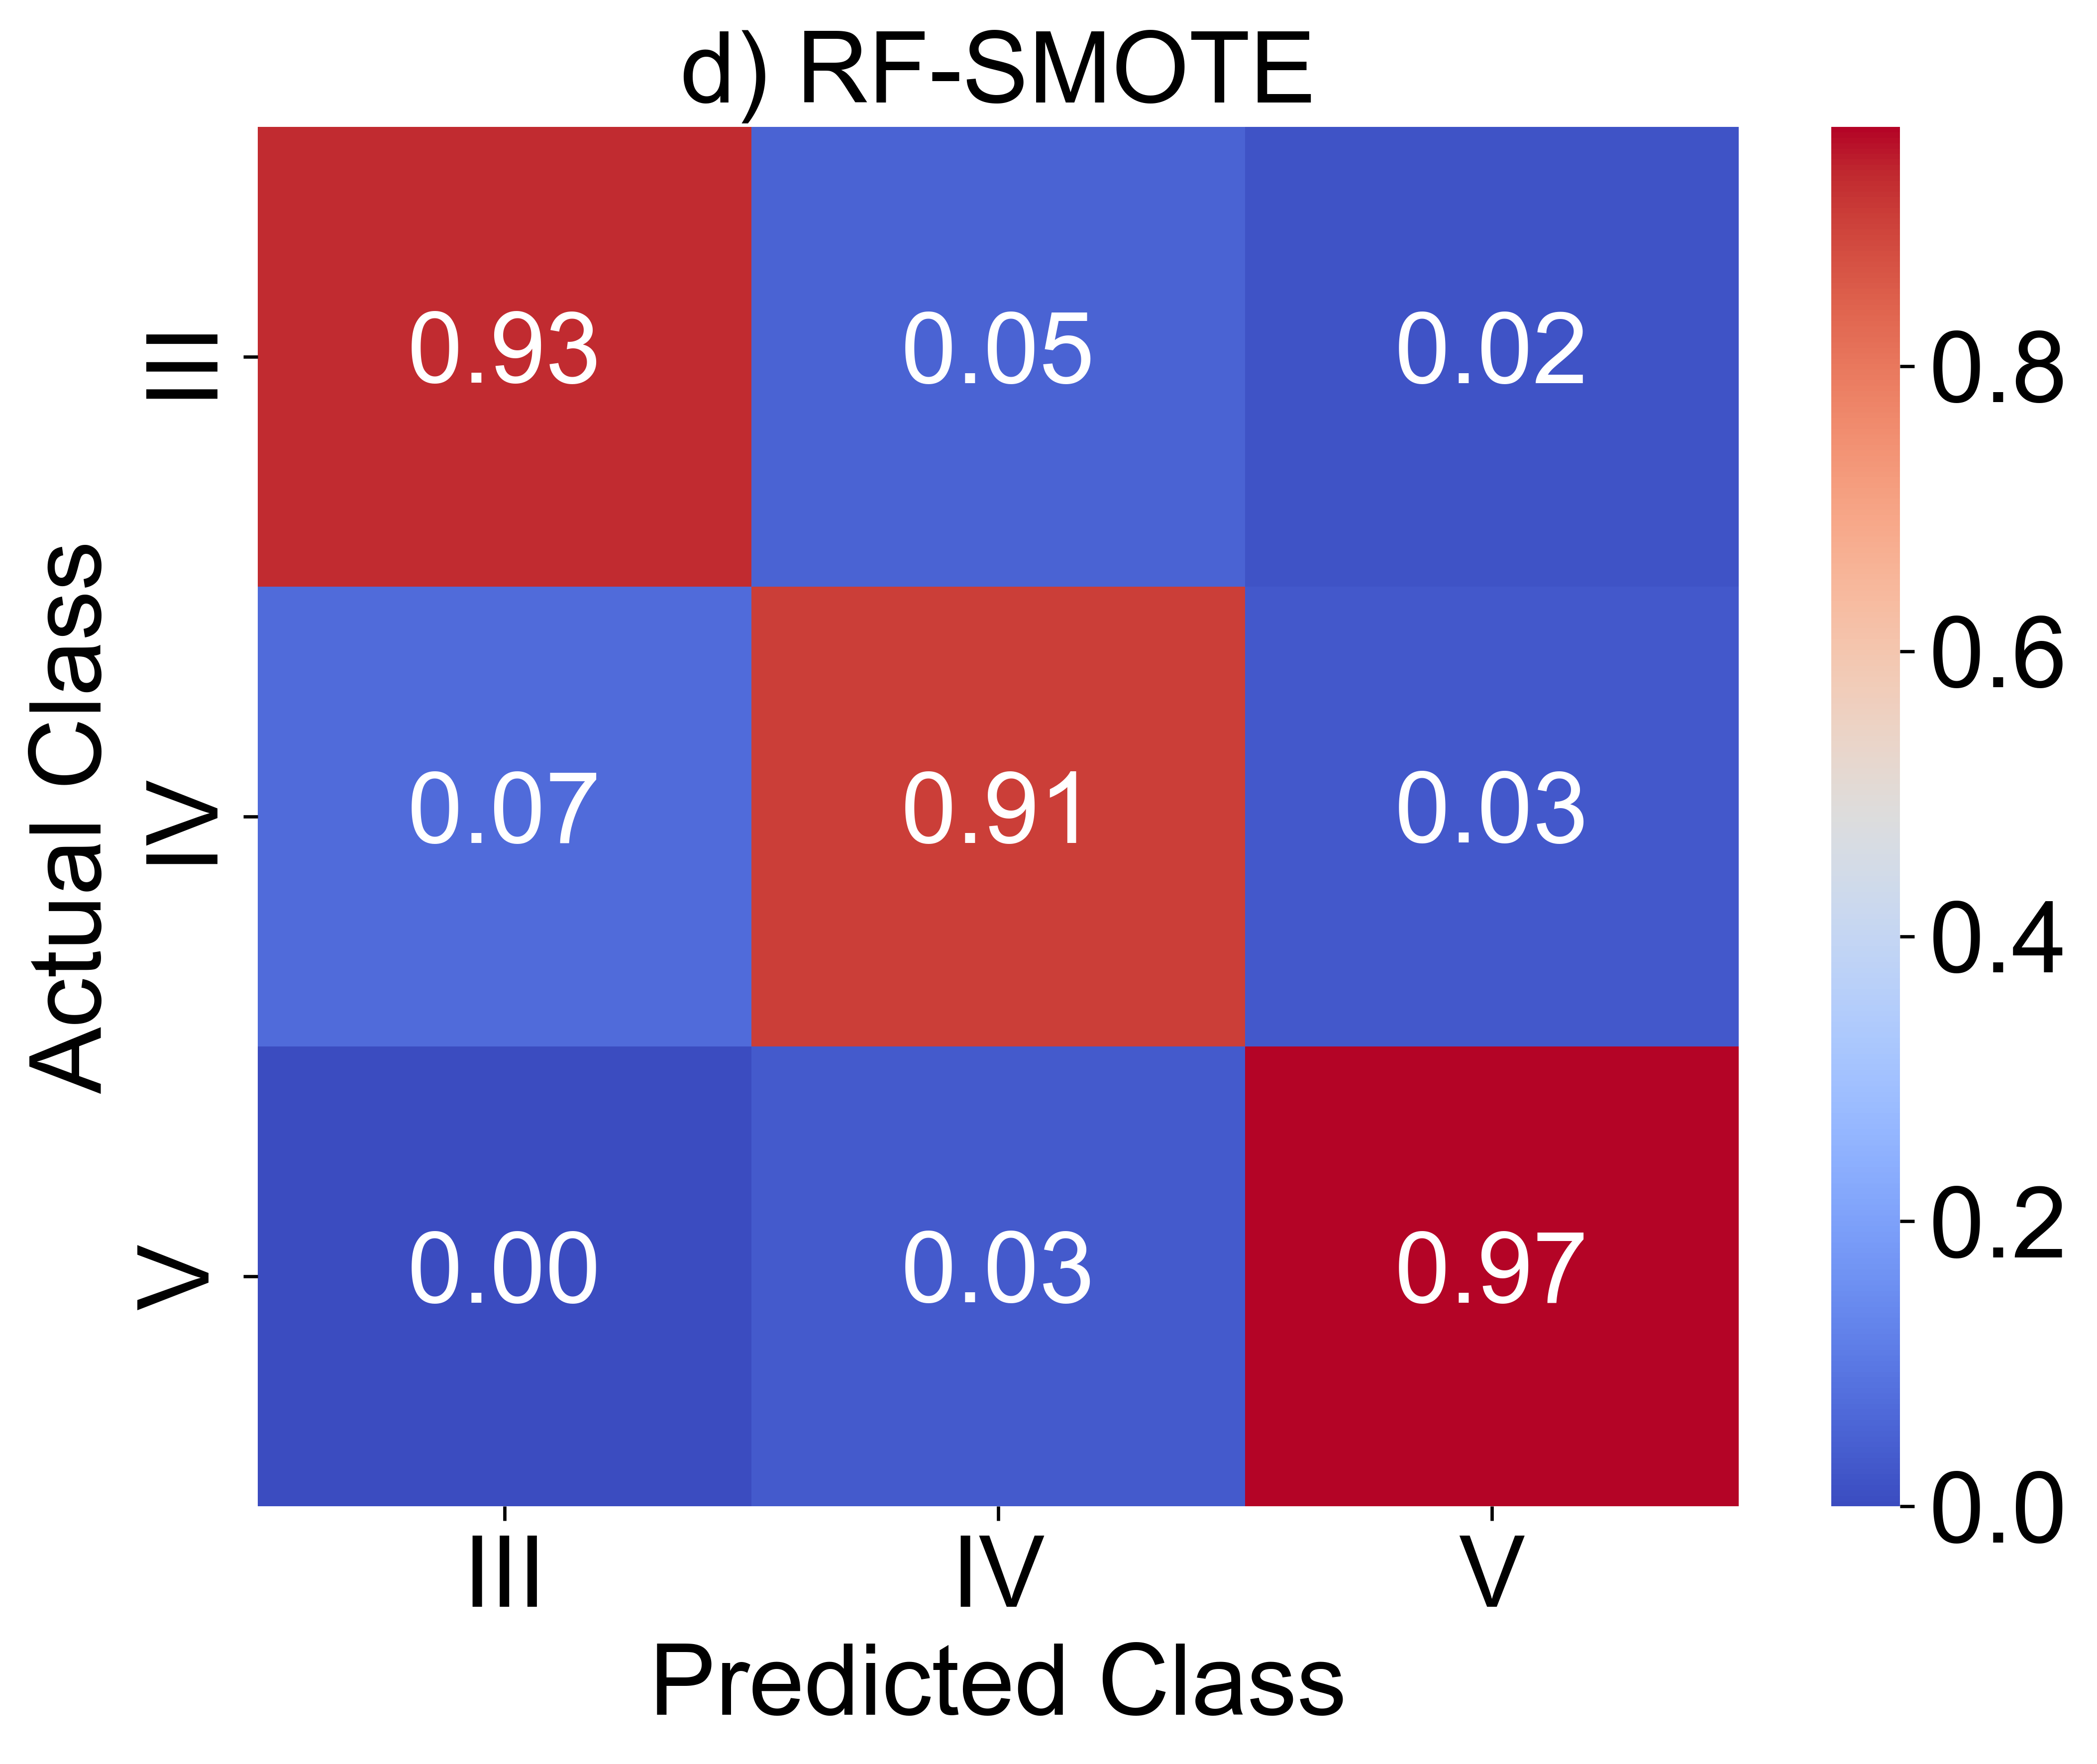

In [7]:
# Set font
plt.rcParams['font.family'] = 'Arial'

# Confusion Matrix
conf_matrix = confusion_matrix(Y_test_decoded, Y_pred_decoded)
# Calculate percentages
conf_matrix_percent = conf_matrix / conf_matrix.sum(axis=1, keepdims=True)

# Plot the confusion matrix heatmap with percentages as decimals
plt.figure(figsize=(8, 6),dpi=600)
heatmap = sns.heatmap(conf_matrix_percent, annot=True, fmt=".2f", cmap="coolwarm",
            xticklabels=original_class_names, yticklabels=original_class_names, annot_kws={"size": 24})

plt.title('d) RF-SMOTE', fontsize=24)
plt.xlabel('Predicted Class', fontsize=24)
plt.ylabel('Actual Class', fontsize=24)
# Increase x and y label size
heatmap.set_xticklabels(heatmap.get_xticklabels(), fontsize=24)
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize=24)
# Get the colorbar axes and set the label size
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=24)
plt.show()

# PR Curve Visualization

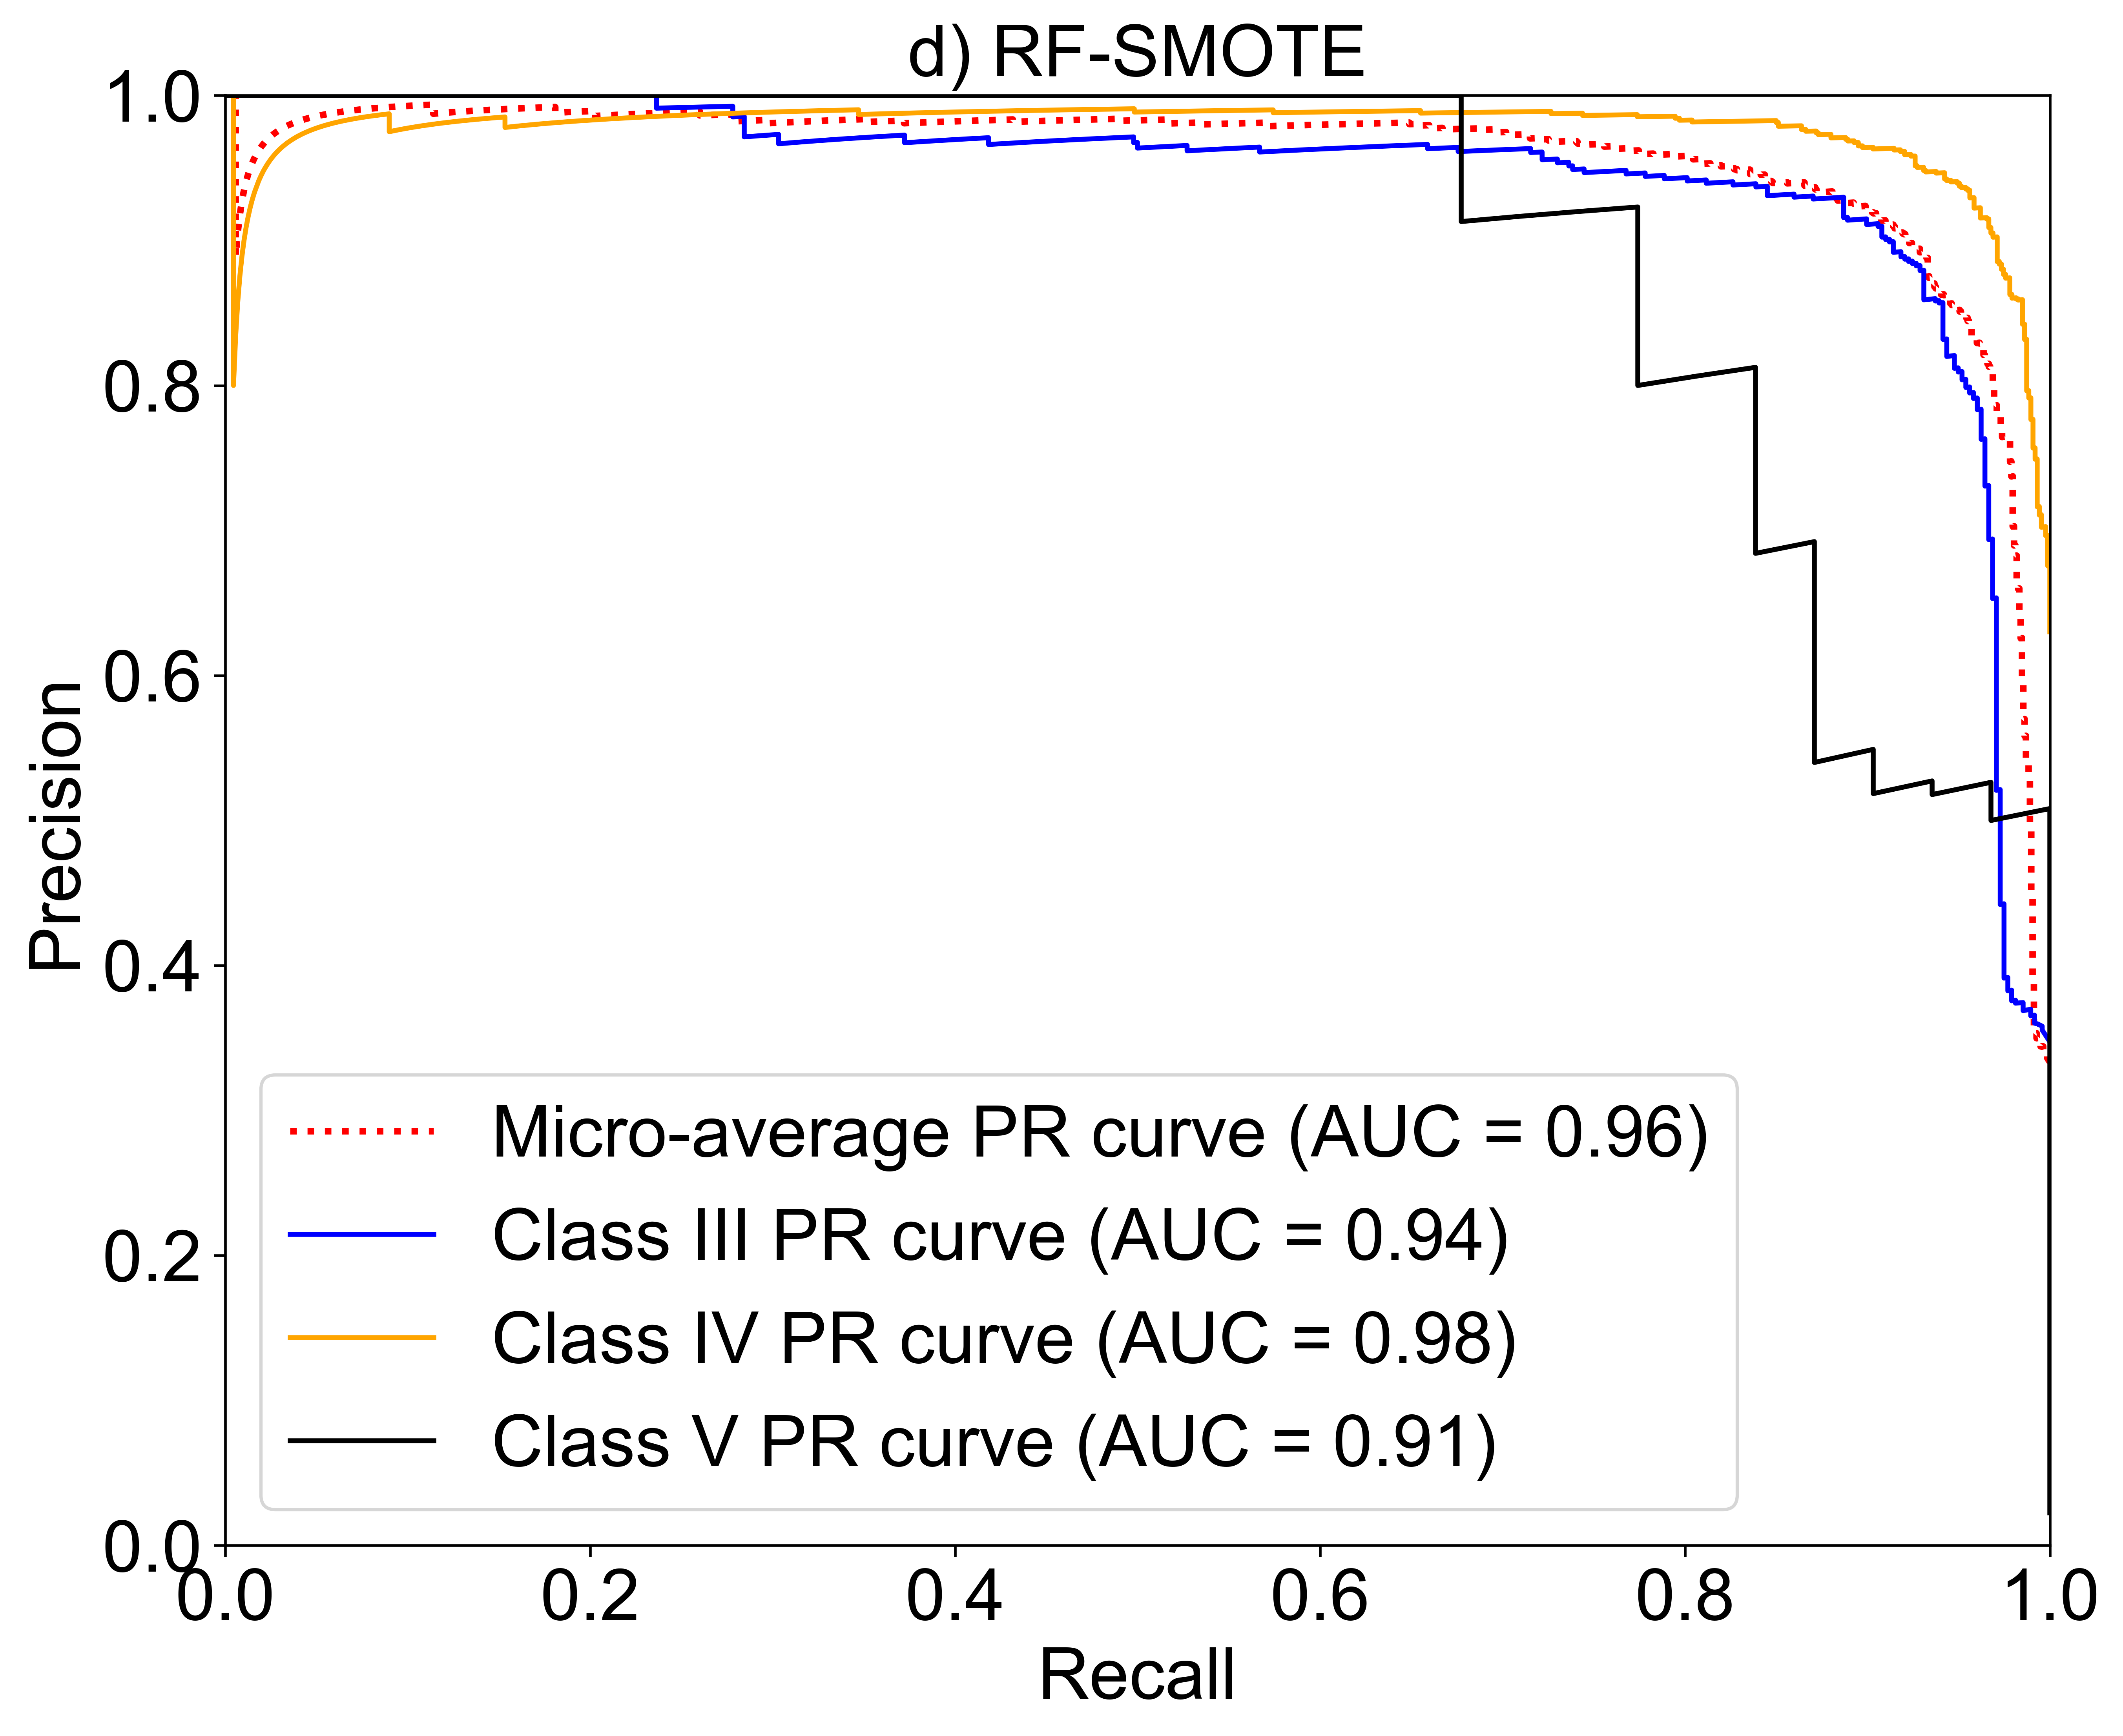

In [8]:
# Set font
plt.rcParams['font.family'] = 'Arial'

# Model Evaluation
Y_pred_proba = classifier.predict_proba(X_test_standardized)

# Compute Precision-Recall curve and AUC for each class
precision = dict()
recall = dict()
average_precision = dict()


for i, class_label in enumerate(classifier.classes_):
    binary_true_labels = (Y_test == class_label).astype(int)
    precision[i], recall[i], thresholds = precision_recall_curve(binary_true_labels, Y_pred_proba[:, i])
    average_precision[i] = average_precision_score(binary_true_labels, Y_pred_proba[:, i])

# Compute micro-average Precision-Recall curve and AUC
precision_micro, recall_micro, thresholds_micro = precision_recall_curve(pd.get_dummies(Y_test).values.ravel(), Y_pred_proba.ravel())
average_precision_micro = average_precision_score(pd.get_dummies(Y_test).values.ravel(), Y_pred_proba.ravel())




# Define colors and line styles
class_colors = {'III': 'blue', 'IV': 'orange', 'V': 'black'}
class_linestyles = {'III': '-', 'IV': '-', 'V': '-'}
micro_color = 'red'
micro_linestyle = ':'
no_skill_label = 'No Skill'
no_skill_color = 'cyan'

# Plot Precision-Recall curves for each class and micro-average
plt.figure(figsize=(10, 8), dpi=600)
plt.plot(recall_micro, precision_micro, label=f'Micro-average PR curve (AUC = {average_precision_micro:.2f})', color=micro_color, linestyle=micro_linestyle, linewidth=2)
for i, class_label in enumerate(classifier.classes_):
    plt.plot(recall[i], precision[i], label=f'Class {original_class_names[i]} PR curve (AUC = {average_precision[i]:.2f})', color=class_colors[original_class_names[i]], linestyle=class_linestyles[original_class_names[i]])



plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])

plt.xlabel('Recall', fontsize=22)
plt.ylabel('Precision', fontsize=22)
plt.title('d) RF-SMOTE', fontsize=22)  # You can change the title if needed

# Set tick label size
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)

# Set legend
plt.legend(loc='lower left', fontsize=22)

# Show the plot
plt.show()

# ROC Curve Visualization

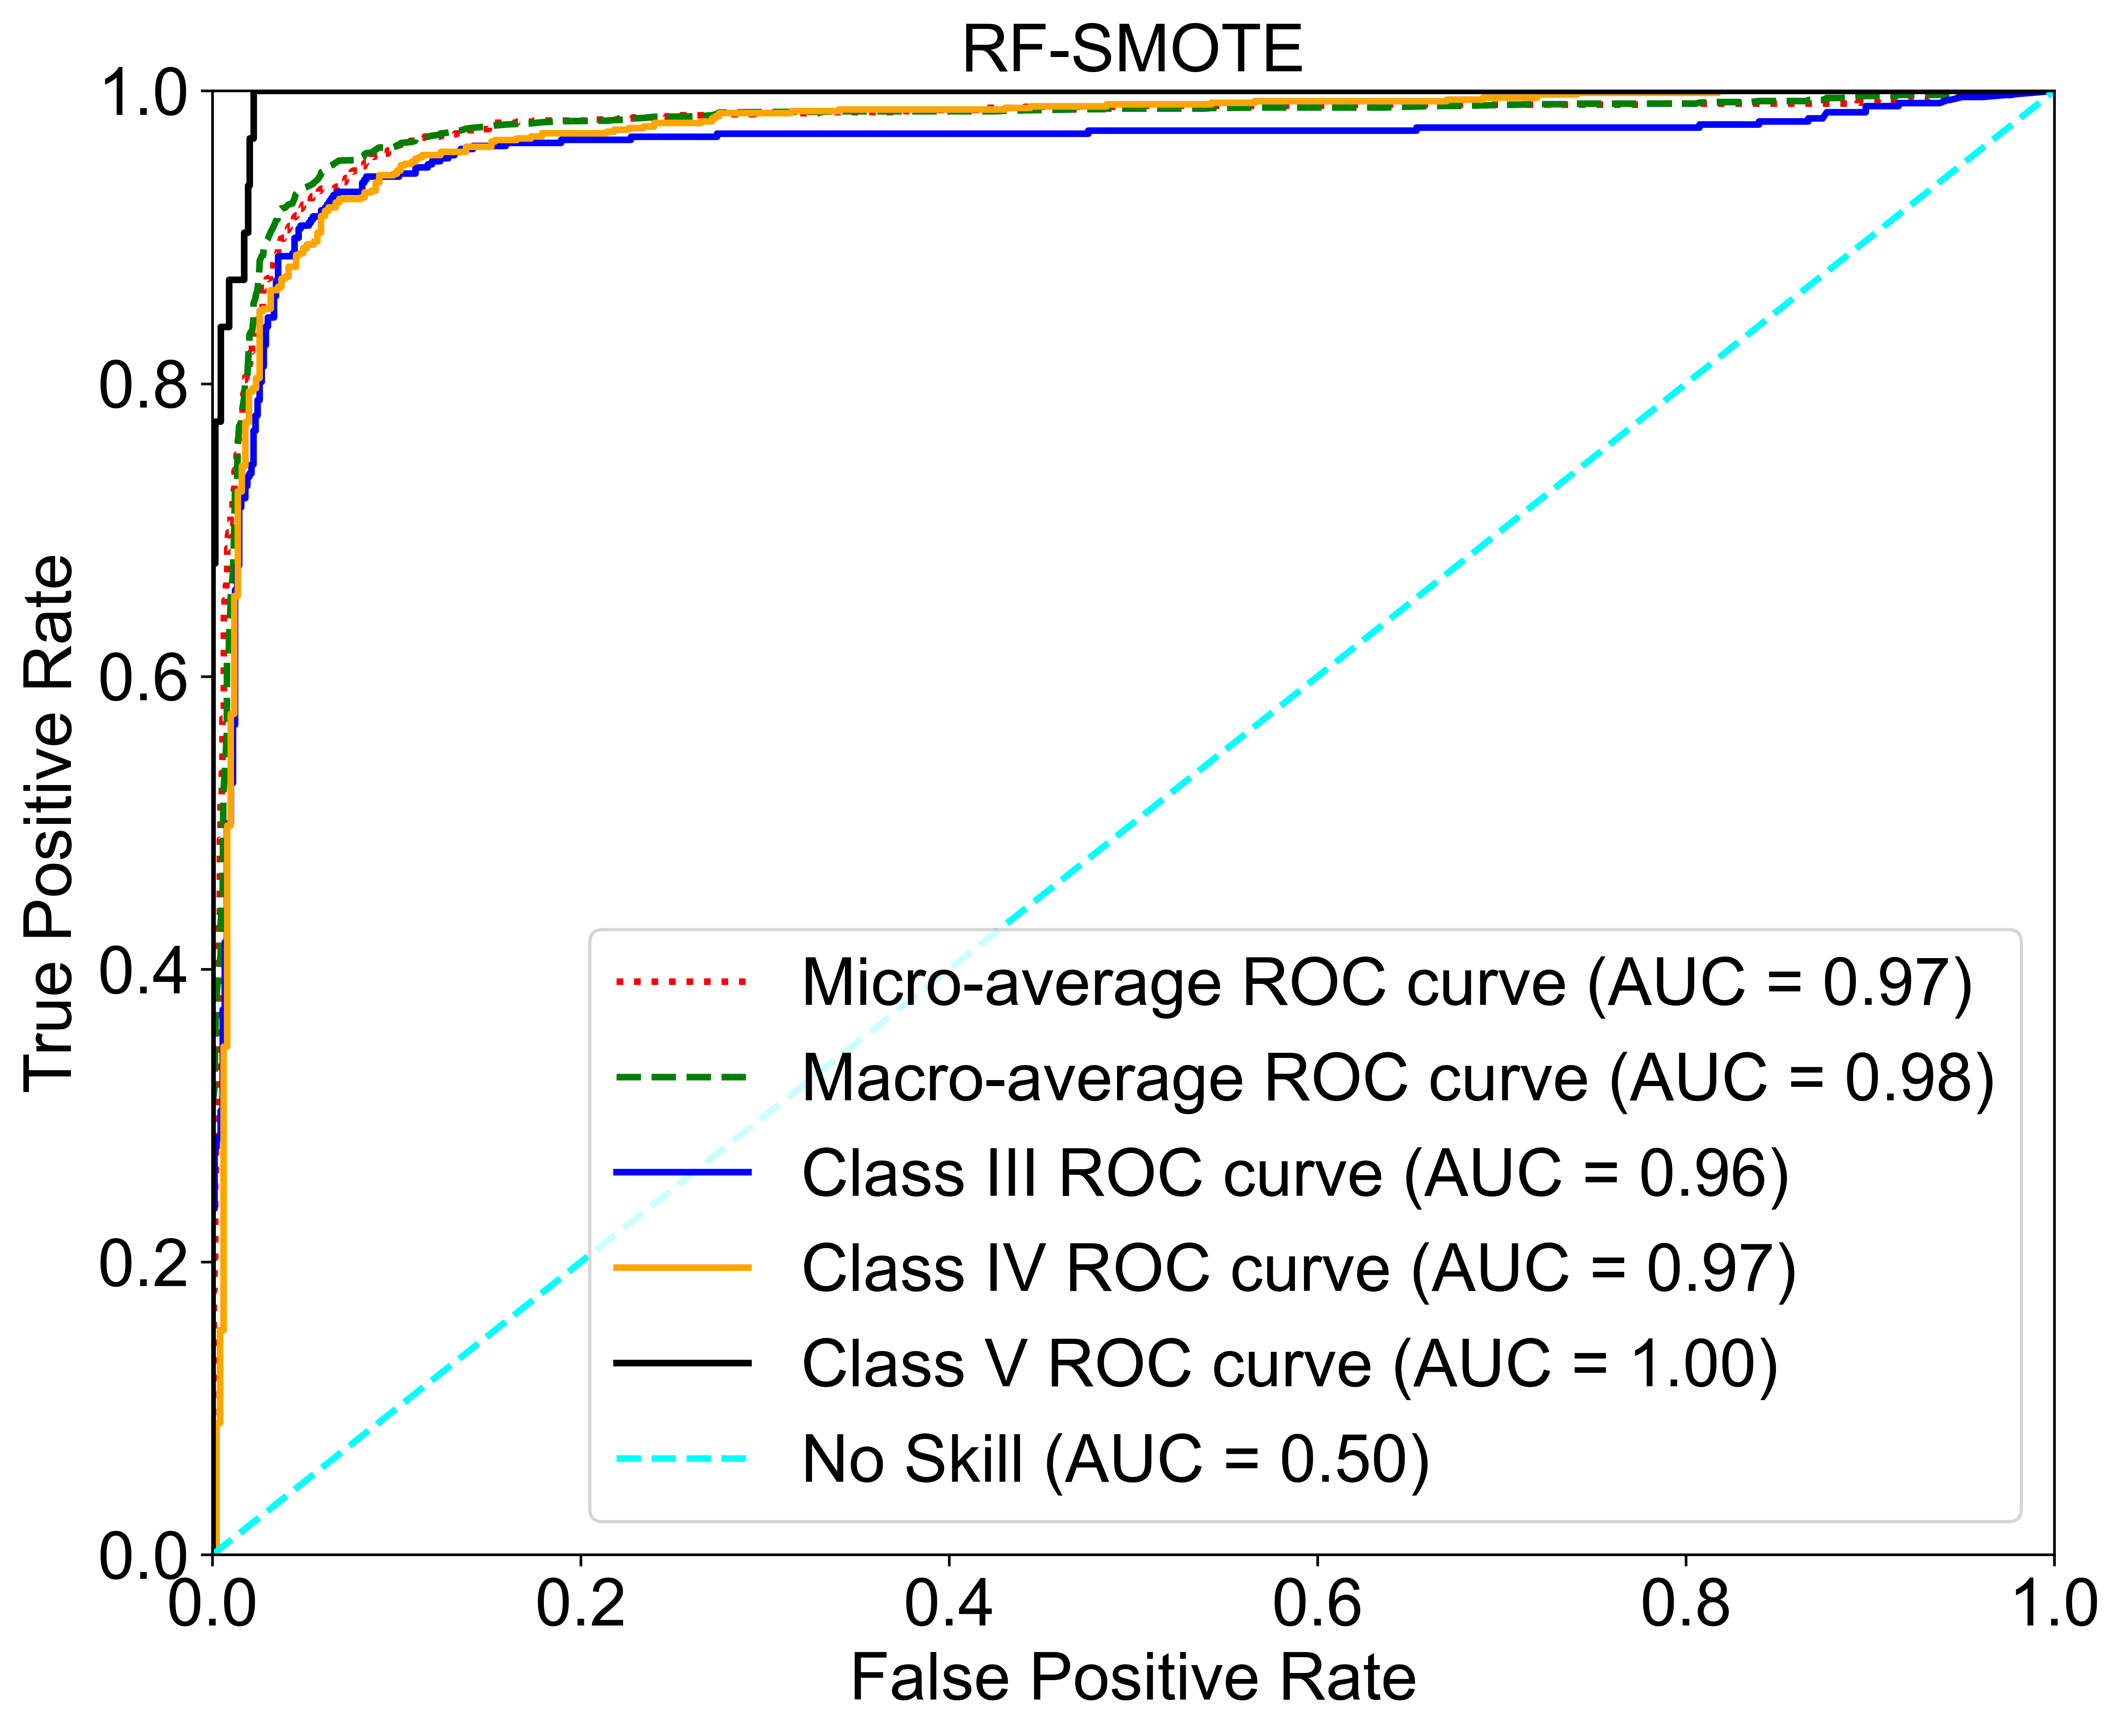

In [9]:
# Set font
plt.rcParams['font.family'] = 'Arial'

# Model Evaluation
Y_pred_proba = classifier.predict_proba(X_test_standardized)


# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()


for i, class_label in enumerate(classifier.classes_):
    binary_true_labels = (Y_test == class_label).astype(int)
    fpr[i], tpr[i], _ = roc_curve(binary_true_labels, Y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr_micro, tpr_micro, _ = roc_curve(pd.get_dummies(Y_test).values.ravel(), Y_pred_proba.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

# Compute macro-average ROC curve and AUC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(classifier.classes_))]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(len(classifier.classes_)):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= len(classifier.classes_)
fpr_macro = all_fpr
tpr_macro = mean_tpr
roc_auc_macro = auc(fpr_macro, tpr_macro)


# Define colors and line styles
class_colors = {'III': 'blue', 'IV': 'orange', 'V': 'black'}
class_linestyles = {'III': '-', 'IV': '-', 'V': '-'}
macro_color = 'green'
micro_color = 'red'
macro_linestyle = '--'
micro_linestyle = ':'
no_skill_label = 'No Skill'
no_skill_color = 'cyan'

# Plot ROC curves with custom colors and line styles
plt.figure(figsize=(10, 8), dpi=600)
plt.plot(fpr_micro, tpr_micro, label=f'Micro-average ROC curve (AUC = {roc_auc_micro:.2f})', color=micro_color, linestyle=micro_linestyle, linewidth=2)
plt.plot(fpr_macro, tpr_macro, label=f'Macro-average ROC curve (AUC = {roc_auc_macro:.2f})', color=macro_color, linestyle=macro_linestyle, linewidth=2)

for i, class_label in enumerate(classifier.classes_):
    plt.plot(fpr[i], tpr[i], label=f'Class {original_class_names[i]} ROC curve (AUC = {roc_auc[i]:.2f})', color=class_colors[original_class_names[i]], linestyle=class_linestyles[original_class_names[i]], linewidth=2)



# Plot the "No Skill" line
plt.plot([0, 1], [0, 1], color=no_skill_color, linestyle='--', label=f'{no_skill_label} (AUC = 0.50)', linewidth=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])

plt.xlabel('False Positive Rate', fontsize=20)
plt.ylabel('True Positive Rate', fontsize=20)
plt.title('RF-SMOTE', fontsize=20)  # You can change the title if needed

# Set tick label size
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# Set legend
plt.legend(loc='lower right', fontsize=20)

# Show the plot
plt.show()